✔ Data cleaning
✔ Time column set karna
✔ Stationarity check
✔ Differencing
✔ ARIMA model training
✔ Forecasting
✔ Visualization

Step-by-step roadmap:
Data Cleaning ✅, 
EDA (graphs banane), 
Time Series Conversion, 
ARIMA model, 
SARIMA model, 
Prophet model, 
Model comparison, 
Dashboard (Power BI) 

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Data Analysing

In [2]:
data=pd.read_csv('SmartDairy_Final_Dataset_v2.csv')
df=pd.DataFrame(data)
df

,Date,Product_Name,Region,Quantity_Sold,Price,Temperature,Festival_Indicator,Holiday_Indicator
0,2021-01-01,Milk,North,157,60,7,No,Yes
1,2021-01-01,Milk,South,271,60,7,No,Yes
2,2021-01-01,Milk,East,132,60,7,No,Yes
3,2021-01-01,Milk,West,288,60,7,No,Yes
4,2021-01-01,Curd,North,181,80,7,No,Yes
...,...,...,...,...,...,...,...,...
36515,2025-12-31,Paneer,West,252,400,7,No,No
36516,2025-12-31,Cheese,North,166,600,7,No,No
36517,2025-12-31,Cheese,South,123,600,7,No,No
36518,2025-12-31,Cheese,East,103,600,7,No,No


In [3]:
df.shape

(36520, 8)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36520 entries, 0 to 36519
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Date                36520 non-null  str  
 1   Product_Name        36520 non-null  str  
 2   Region              36520 non-null  str  
 3   Quantity_Sold       36520 non-null  int64
 4   Price               36520 non-null  int64
 5   Temperature         36520 non-null  int64
 6   Festival_Indicator  36520 non-null  str  
 7   Holiday_Indicator   36520 non-null  str  
dtypes: int64(3), str(5)
memory usage: 2.2 MB


In [5]:
df.describe()

,Quantity_Sold,Price,Temperature
count,36520.000000,36520.000000,36520.000000
mean,246.977547,328.000000,24.113910
std,87.214531,220.039373,11.037237
min,100.000000,60.000000,5.000000
25%,179.000000,80.000000,14.000000
50%,239.000000,400.000000,24.000000
75%,298.000000,500.000000,33.000000
max,538.000000,600.000000,44.000000


In [6]:
df.isnull().sum()

Date                  0
Product_Name          0
Region                0
Quantity_Sold         0
Price                 0
Temperature           0
Festival_Indicator    0
Holiday_Indicator     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
# Data Cleaning

In [11]:
df['Date']=pd.to_datetime(df['Date'])

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36520 entries, 0 to 36519
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                36520 non-null  datetime64[us]
 1   Product_Name        36520 non-null  str           
 2   Region              36520 non-null  str           
 3   Quantity_Sold       36520 non-null  int64         
 4   Price               36520 non-null  int64         
 5   Temperature         36520 non-null  int64         
 6   Festival_Indicator  36520 non-null  str           
 7   Holiday_Indicator   36520 non-null  str           
dtypes: datetime64[us](1), int64(3), str(4)
memory usage: 2.2 MB


In [13]:
df['Festival_Indicator'] = df['Festival_Indicator'].map({
    'Yes':1,
    'No':0
})

In [14]:
df['Holiday_Indicator'] = df['Holiday_Indicator'].map({
    'Yes':1,
    'No':0
})

In [15]:
df = df.sort_values(by='Date') # sorting dates

In [16]:
df=df.reset_index(drop=True)

In [17]:
df.head()

,Date,Product_Name,Region,Quantity_Sold,Price,Temperature,Festival_Indicator,Holiday_Indicator
0,2021-01-01,Milk,North,157,60,7,0,1
1,2021-01-01,Cheese,West,159,600,7,0,1
2,2021-01-01,Cheese,East,304,600,7,0,1
3,2021-01-01,Cheese,South,168,600,7,0,1
4,2021-01-01,Cheese,North,321,600,7,0,1


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36520 entries, 0 to 36519
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                36520 non-null  datetime64[us]
 1   Product_Name        36520 non-null  str           
 2   Region              36520 non-null  str           
 3   Quantity_Sold       36520 non-null  int64         
 4   Price               36520 non-null  int64         
 5   Temperature         36520 non-null  int64         
 6   Festival_Indicator  36520 non-null  int64         
 7   Holiday_Indicator   36520 non-null  int64         
dtypes: datetime64[us](1), int64(5), str(2)
memory usage: 2.2 MB


In [20]:
# Exploratory Data Analysis (EDA)
# checking Trends
# Analyze Seasonality
# Insights nikaalenge

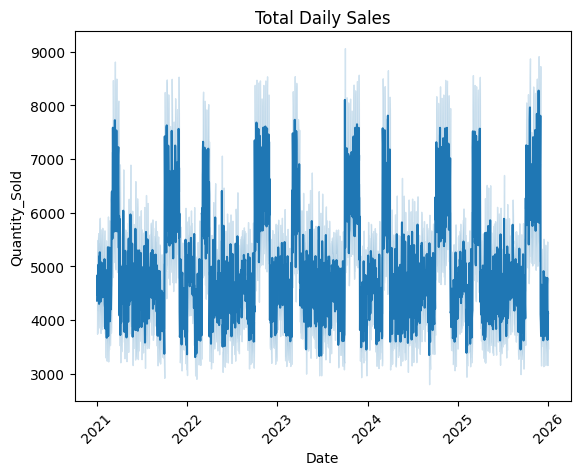

In [23]:
# Total Sales Trend(Overall)
sns.lineplot(data=df,x='Date', y='Quantity_Sold', estimator='sum')
plt.title("Total Daily Sales")
plt.xticks(rotation=45)
plt.show()

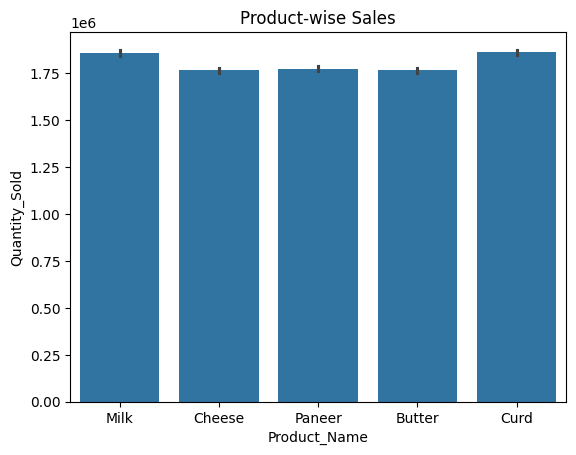

In [28]:
# Product-wise Sales
sns.barplot(data=df,x='Product_Name', y='Quantity_Sold', estimator='sum')
plt.title("Product-wise Sales")
plt.show()

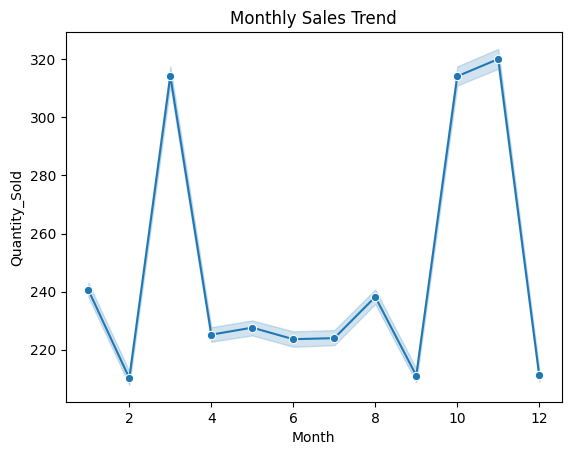

In [30]:
# Monthly Seasonality
df['Month'] = df['Date'].dt.month
sns.lineplot(data=df, x='Month', y='Quantity_Sold', estimator='mean',marker='o' )
plt.title("Monthly Sales Trend")
plt.show()

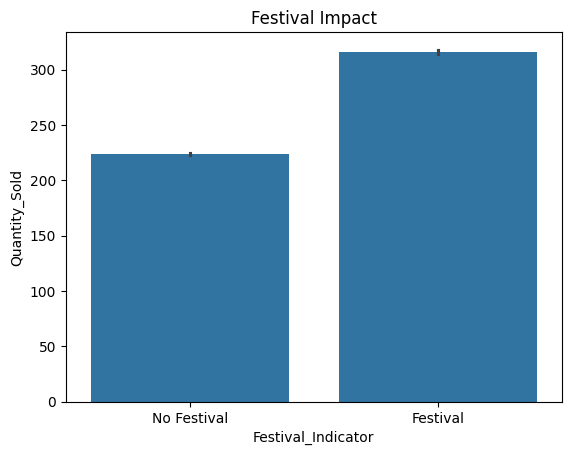

In [31]:
# Festival impact
sns.barplot(data=df,x='Festival_Indicator', y='Quantity_Sold', estimator='mean')
plt.xticks([0,1], ['No Festival','Festival'])
plt.title("Festival Impact")
plt.show()

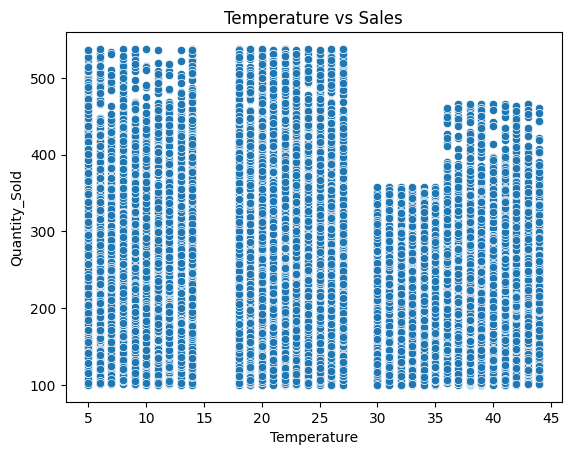

In [32]:
# Temperature vs Sales
sns.scatterplot(data=df,x='Temperature', y='Quantity_Sold')
plt.title("Temperature vs Sales")
plt.show()

In [33]:
# Time Series Preparation (MOST CRITICAL)
# same date has multiple columns
df['Date'].value_counts().head()

Date
2021-01-01    20
2021-01-02    20
2021-01-03    20
2021-01-04    20
2021-01-05    20
Name: count, dtype: int64

In [36]:
#Daily Aggregation
df_ts = df.groupby('Date')['Quantity_Sold'].sum().reset_index()

In [37]:
#Set Date as Index
df_ts.set_index('Date', inplace=True)

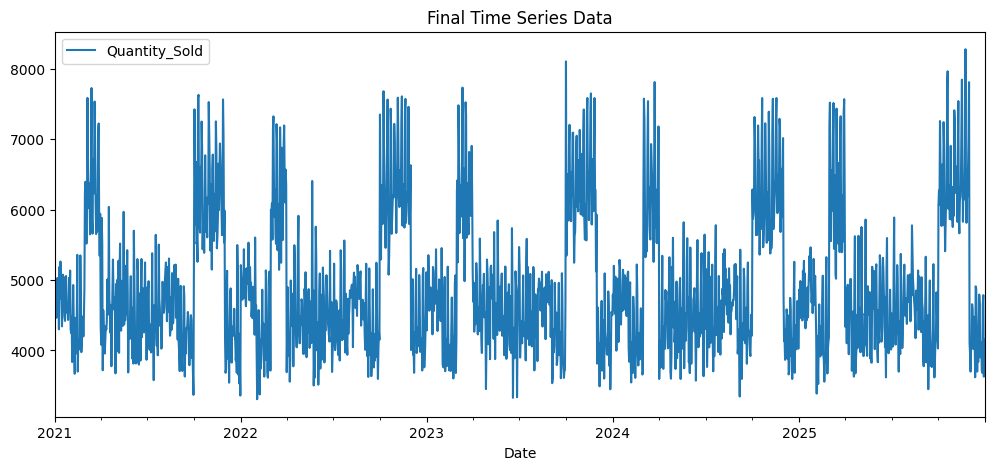

In [38]:
# Plot Clean Time Series
df_ts.plot(figsize=(12,5), title="Final Time Series Data")
plt.show()

In [45]:
# Stationarity Check (ADF Test)
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

In [42]:
result = adfuller(df_ts['Quantity_Sold'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -7.242515273002681
p-value: 1.868320596824047e-10


In [43]:
# using ARIMA

In [46]:
train = df_ts[:'2024']
test = df_ts['2025':]

In [48]:
model = ARIMA(train['Quantity_Sold'], order=(1,0,1))
model_fit = model.fit()

C:\Users\Lalit\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Lalit\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Lalit\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [49]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:          Quantity_Sold   No. Observations:                 1461
Model:                 ARIMA(1, 0, 1)   Log Likelihood              -11516.729
Date:                Wed, 01 Apr 2026   AIC                          23041.459
Time:                        19:31:02   BIC                          23062.606
Sample:                    01-01-2021   HQIC                         23049.347
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       4936.1598    140.194     35.210      0.000    4661.385    5210.935
ar.L1          0.9446      0.010     98.610      0.000       0.926       0.963
ma.L1         -0.5797      0.023    -25.656      0.000      -0.624      -0.535
sigma2      4.112e+05   1.15e+04     35.634      0.000    3.89e+05    4.34e+05
===================================================================================
Ljung-Box (L1) (Q):                  27.87   Jarque-Bera (JB):               393.83
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.12   Skew:                             0.64
Prob(H) (two-sided):                  0.21   Kurtosis:                         5.20
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [50]:
forecast = model_fit.forecast(steps=len(test))

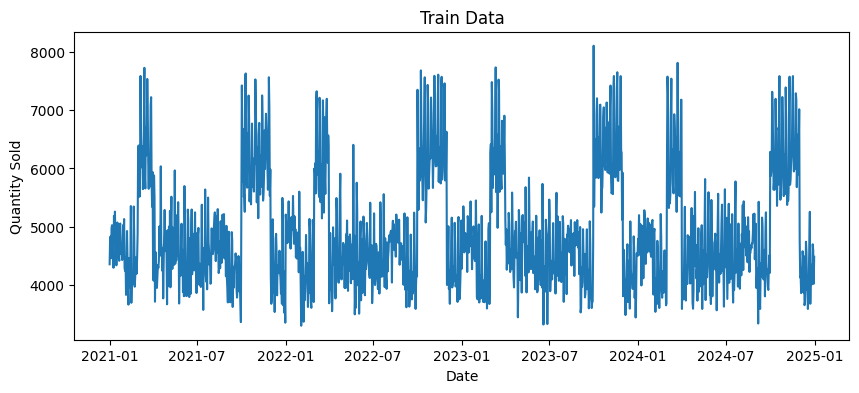

In [54]:
# Train Plot
plt.figure(figsize=(10,4))
sns.lineplot(x=train.index, y=train['Quantity_Sold'])
plt.title("Train Data")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.show()

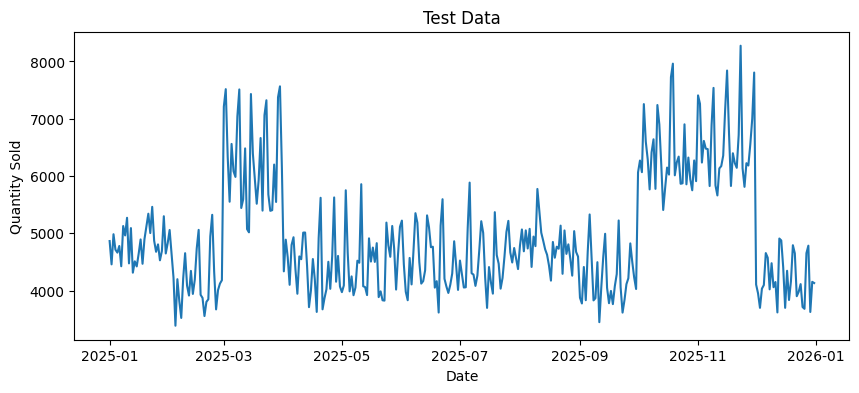

In [55]:
# Test Plot
plt.figure(figsize=(10,4))
sns.lineplot(x=test.index, y=test['Quantity_Sold'])
plt.title("Test Data")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.show()

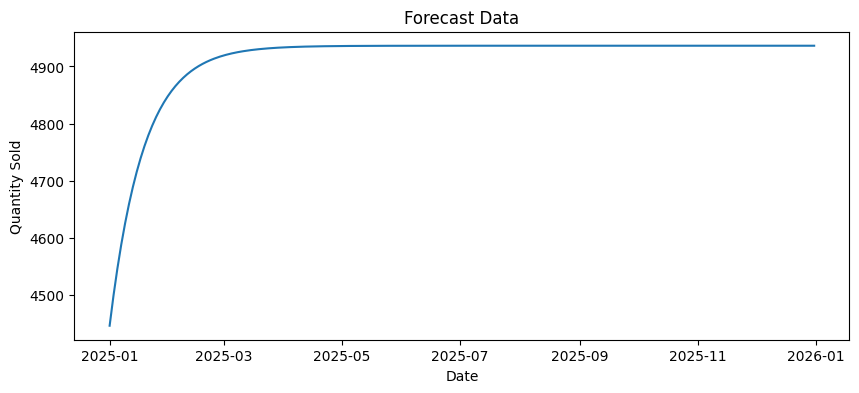

In [56]:
# Forecast Plot
plt.figure(figsize=(10,4))
sns.lineplot(x=test.index, y=forecast)
plt.title("Forecast Data")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.show()

In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [62]:
# MAE : mean absolute error
mean_absolute_error(test['Quantity_Sold'], forecast)

794.9070943370647

In [64]:
# RMSE : mean squared error
np.sqrt(mean_squared_error(test['Quantity_Sold'], forecast))

np.float64(1004.5402794764826)

In [65]:
# MAPE : 
np.mean(np.abs((test['Quantity_Sold'] - forecast) / test['Quantity_Sold'])) * 100

np.float64(15.785185286452247)

In [67]:
# using SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [75]:
# model = SARIMAX(train['Quantity_Sold'],order=(1,0,1),seasonal_order=(1,1,1,12))
model = SARIMAX(train['Quantity_Sold'],order=(1,0,1),seasonal_order=(1,1,1,7))
model_fit = model.fit()

C:\Users\Lalit\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Lalit\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [76]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                     Quantity_Sold   No. Observations:                 1461
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 7)   Log Likelihood              -11162.312
Date:                           Wed, 01 Apr 2026   AIC                          22334.623
Time:                                   20:35:54   BIC                          22361.033
Sample:                               01-01-2021   HQIC                         22344.477
                                    - 12-31-2024                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9512      0.010     97.025      0.000       0.932       0.970
ma.L1         -0.5360      0.021    -25.608      0.000      -0.577      -0.495
ar.S.L7        0.1098      0.028      3.910      0.000       0.055       0.165
ma.S.L7       -1.0000      0.024    -41.918      0.000      -1.047      -0.953
sigma2      2.651e+05      9e-08   2.95e+12      0.000    2.65e+05    2.65e+05
===================================================================================
Ljung-Box (L1) (Q):                   2.63   Jarque-Bera (JB):               881.97
Prob(Q):                              0.10   Prob(JB):                         0.00
Heteroskedasticity (H):               1.00   Skew:                             0.33
Prob(H) (two-sided):                  0.96   Kurtosis:                         6.76
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.47e+26. Standard errors may be unstable.
"""

In [77]:
forecast = model_fit.forecast(steps=len(test))

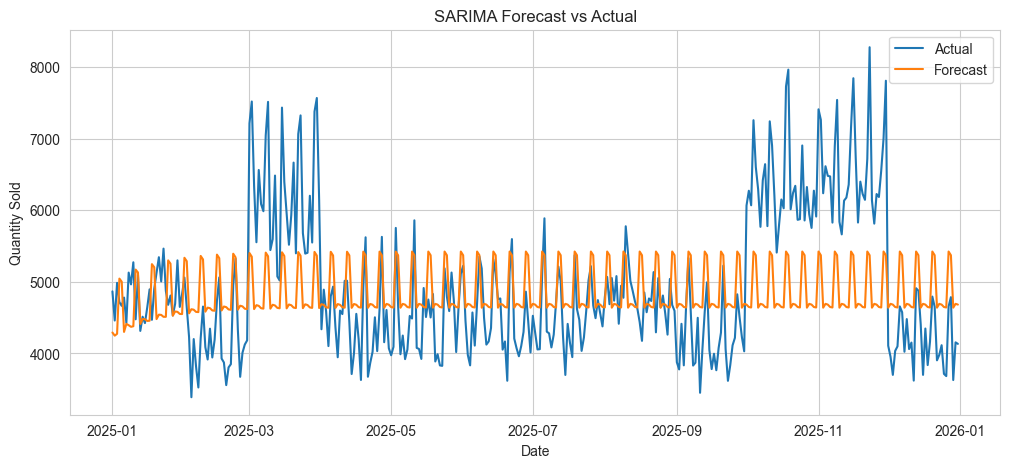

In [78]:
plt.figure(figsize=(12,5))

sns.lineplot(x=test.index, y=test['Quantity_Sold'], label='Actual')
sns.lineplot(x=test.index, y=forecast, label='Forecast')

plt.title("SARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")

plt.legend()
plt.show()

In [79]:
from pmdarima import auto_arima

In [80]:
auto_model = auto_arima(train['Quantity_Sold'],seasonal=True,m=7,trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=inf, Time=9.06 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=24219.530, Time=0.18 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=22844.718, Time=2.69 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=23214.596, Time=1.28 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=29052.271, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[7] intercept   : AIC=23134.203, Time=0.36 sec
 ARIMA(1,0,0)(2,0,0)[7] intercept   : AIC=22818.388, Time=7.02 sec
 ARIMA(1,0,0)(2,0,1)[7] intercept   : AIC=22822.294, Time=14.17 sec
 ARIMA(1,0,0)(1,0,1)[7] intercept   : AIC=22846.600, Time=3.18 sec
 ARIMA(0,0,0)(2,0,0)[7] intercept   : AIC=24123.206, Time=5.87 sec
 ARIMA(2,0,0)(2,0,0)[7] intercept   : AIC=22759.765, Time=12.67 sec
 ARIMA(2,0,0)(1,0,0)[7] intercept   : AIC=22795.368, Time=4.35 sec


C:\Users\Lalit\AppData\Local\Programs\Python\Python311\Lib\site-packages\pmdarima\arima\_auto_solvers.py:524: ModelFitWarning: Error fitting  ARIMA(2,0,0)(2,0,1)[7] intercept (if you do not want to see these warnings, run with error_action="ignore").
Traceback:
Traceback (most recent call last):
  File "C:\Users\Lalit\AppData\Local\Programs\Python\Python311\Lib\site-packages\pmdarima\arima\_auto_solvers.py", line 508, in _fit_candidate_model
    fit.fit(y, X=X, **fit_params)
  File "C:\Users\Lalit\AppData\Local\Programs\Python\Python311\Lib\site-packages\pmdarima\arima\arima.py", line 610, in fit
    self._fit(y, X, **fit_args)
  File "C:\Users\Lalit\AppData\Local\Programs\Python\Python311\Lib\site-packages\pmdarima\arima\arima.py", line 531, in _fit
    fit, self.arima_res_ = _fit_wrapper()
                           ^^^^^^^^^^^^^^
  File "C:\Users\Lalit\AppData\Local\Programs\Python\Python311\Lib\site-packages\pmdarima\arima\arima.py", line 517, in _fit_wrapper
    fitted = arima.fit

 ARIMA(2,0,0)(2,0,1)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(2,0,0)(1,0,1)[7] intercept   : AIC=22795.614, Time=6.39 sec
 ARIMA(3,0,0)(2,0,0)[7] intercept   : AIC=22685.927, Time=18.41 sec
 ARIMA(3,0,0)(1,0,0)[7] intercept   : AIC=inf, Time=18.00 sec
 ARIMA(3,0,0)(2,0,1)[7] intercept   : AIC=22684.405, Time=58.11 sec
 ARIMA(3,0,0)(1,0,1)[7] intercept   : AIC=22727.484, Time=16.89 sec
 ARIMA(3,0,0)(2,0,2)[7] intercept   : AIC=inf, Time=47.99 sec
 ARIMA(3,0,0)(1,0,2)[7] intercept   : AIC=22702.488, Time=36.32 sec
 ARIMA(4,0,0)(2,0,1)[7] intercept   : AIC=22668.740, Time=57.59 sec
 ARIMA(4,0,0)(1,0,1)[7] intercept   : AIC=22707.653, Time=25.67 sec
 ARIMA(4,0,0)(2,0,0)[7] intercept   : AIC=22667.468, Time=44.25 sec
 ARIMA(4,0,0)(1,0,0)[7] intercept   : AIC=22757.612, Time=5.73 sec
 ARIMA(5,0,0)(2,0,0)[7] intercept   : AIC=22663.064, Time=64.12 sec
 ARIMA(5,0,0)(1,0,0)[7] intercept   : AIC=22732.871, Time=27.20 sec
 ARIMA(5,0,0)(2,0,1)[7] intercept   : AIC=22665.219, Time=70.47 sec
 A

In [81]:
print(auto_model.summary())

                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                 1461
Model:             SARIMAX(5, 0, 0)x(2, 0, 0, 7)   Log Likelihood              -11322.532
Date:                           Wed, 01 Apr 2026   AIC                          22663.064
Time:                                   20:54:27   BIC                          22710.646
Sample:                               01-01-2021   HQIC                         22680.813
                                    - 12-31-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    729.0217     65.659     11.103      0.000     600.333     857.711
ar.L1          0.4278      0.021     19.917

In [91]:
model = SARIMAX(train['Quantity_Sold'],order=(5,1,0),seasonal_order=(2,1,0,7))
model_fit = model.fit()
print(model_fit.summary())

C:\Users\Lalit\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Lalit\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                     Quantity_Sold   No. Observations:                 1461
Model:             SARIMAX(5, 1, 0)x(2, 1, 0, 7)   Log Likelihood              -11323.191
Date:                           Wed, 01 Apr 2026   AIC                          22662.381
Time:                                   21:41:47   BIC                          22704.632
Sample:                               01-01-2021   HQIC                         22678.146
                                    - 12-31-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5260      0.021    -24.944      0.000      -0.567      -0.485
ar.L2         -0.3496      0.028    -12.344

In [92]:
forecast = model_fit.forecast(steps=len(test))

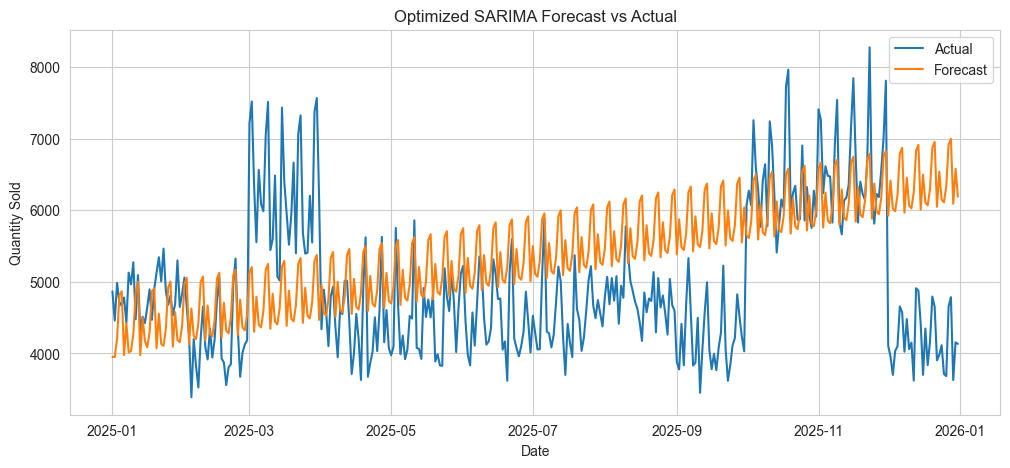

In [93]:
plt.figure(figsize=(12,5))

sns.lineplot(x=test.index, y=test['Quantity_Sold'], label='Actual')
sns.lineplot(x=test.index, y=forecast, label='Forecast')

plt.title("Optimized SARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")

plt.legend()
plt.show()

In [94]:
#MAE
mean_absolute_error(test['Quantity_Sold'], forecast)

928.3160270123491

In [95]:
#RAMSE
mean_absolute_error(test['Quantity_Sold'], forecast)

928.3160270123491

In [96]:
#MAPE
np.mean(np.abs((test['Quantity_Sold'] - forecast) / test['Quantity_Sold'])) * 100

np.float64(20.082677999554708)

In [103]:
df_prophet = df_ts.reset_index()
df_prophet.columns = ['ds', 'y']

In [104]:
# Using prophet model
from prophet import Prophet

In [106]:
prophet_model = Prophet()
prophet_model.fit(df_prophet)

21:55:10 - cmdstanpy - INFO - Chain [1] start processing
21:55:14 - cmdstanpy - INFO - Chain [1] done processing


In [107]:
future = prophet_model.make_future_dataframe(periods=365)

In [109]:
forecast_prophet = prophet_model.predict(future)

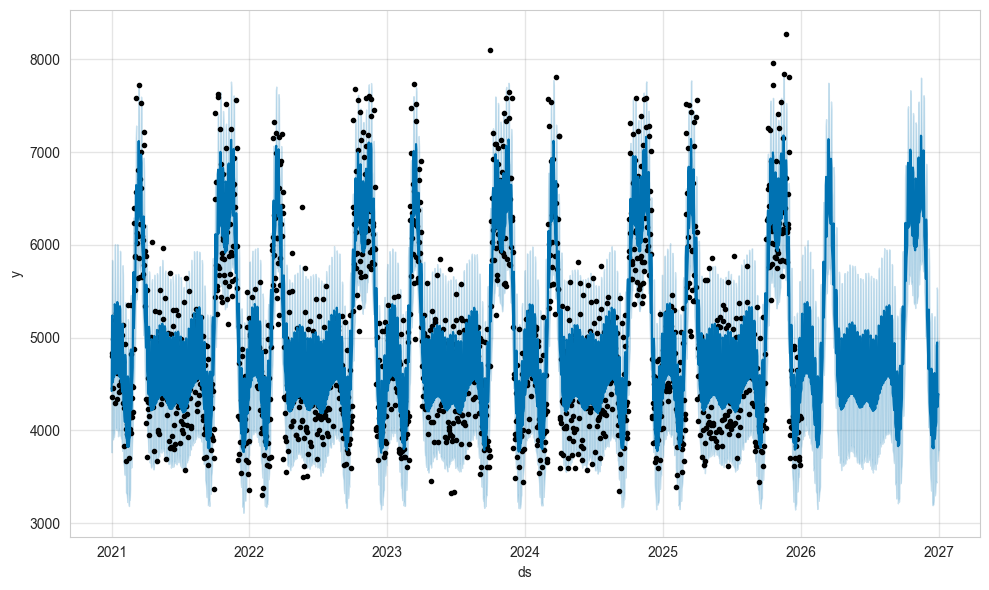

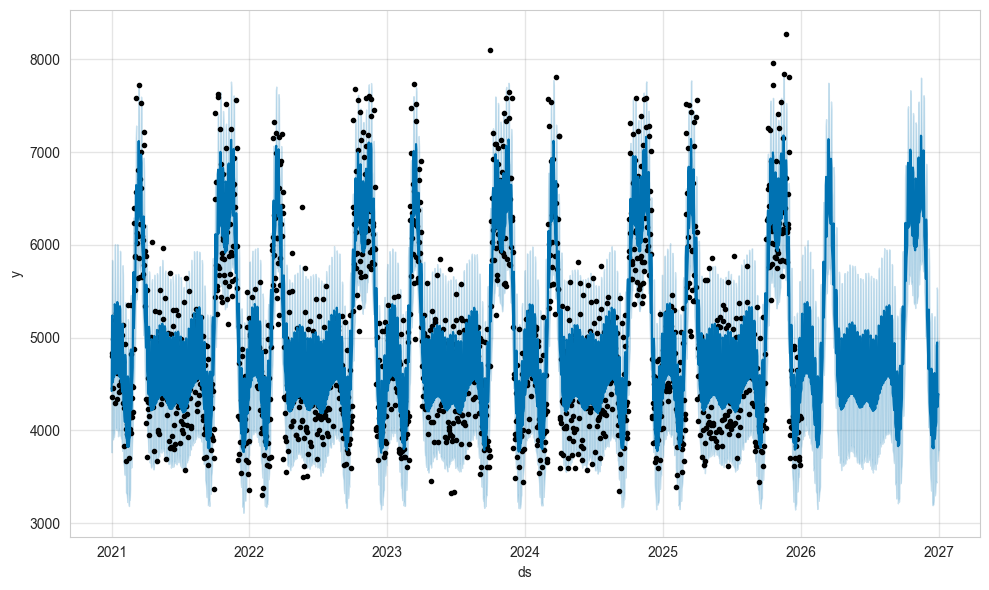

In [110]:
prophet_model.plot(forecast_prophet)

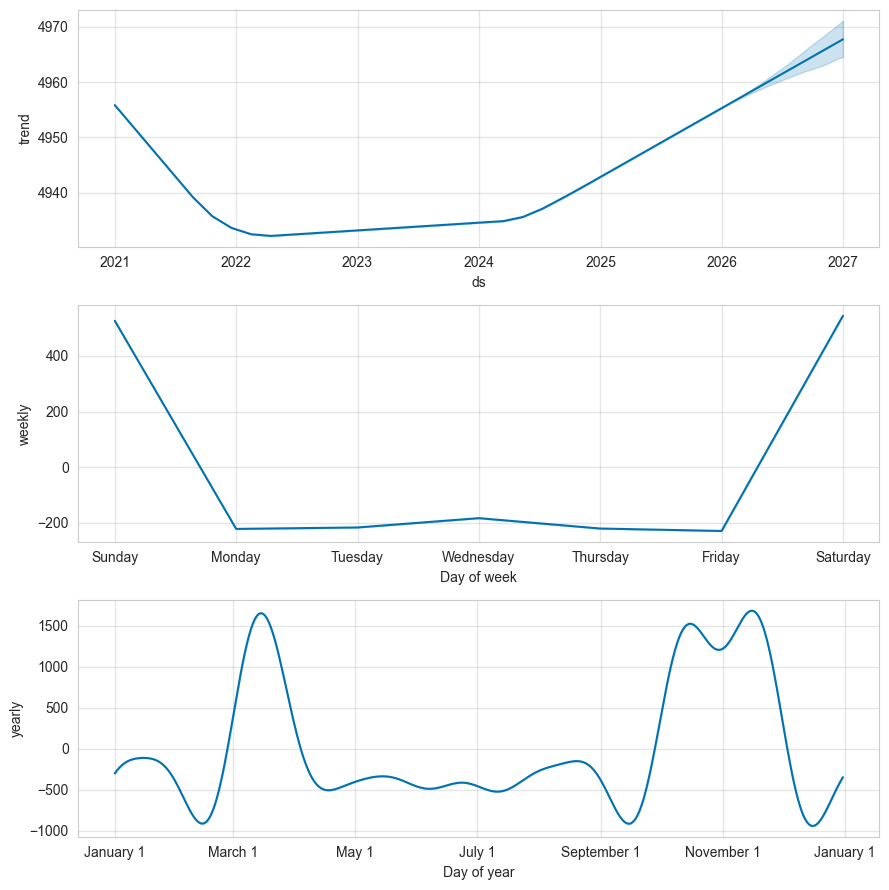

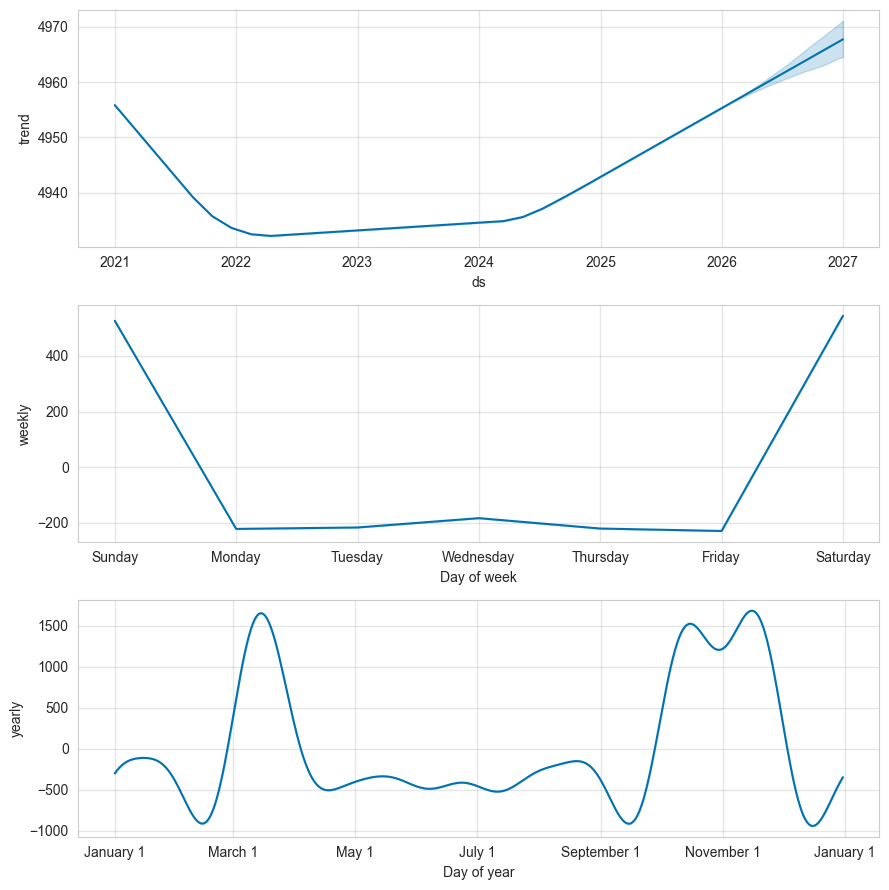

In [111]:
prophet_model.plot_components(forecast_prophet)

In [116]:
# forecast_prophet
df1=forecast_prophet[['ds','yhat']]

In [117]:
df1.head()

,ds,yhat
0,2021-01-01,4424.852753
1,2021-01-02,5230.690919
2,2021-01-03,5241.424051
3,2021-01-04,4519.284562
4,2021-01-05,4546.025372


In [119]:
# Type column add
df1['type'] = df1['ds'].apply(lambda x: 'Actual' if pd.to_datetime(x).year <= 2025 else 'Forecast')
# Save again
df1.to_csv("Smart_final_data.csv", index=False)